In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent and professional looking color theme
sns.set_theme(style="whitegrid", palette="viridis")

# You can also customize figure size for better readability
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported and visualization theme set.")

Libraries imported and visualization theme set.


Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

try:
     file_path = '/content/drive/MyDrive/Marketing AB Testing/df_cleaned_final.csv'
     df = pd.read_csv(file_path)
     print('Dataset loaded successfully!')
     display(df.head())
except FileNotFoundError:
     print(f"Error: The file at '{file_path}' was not found. Please check the path.")
except Exception as e:
     print(f"An error occurred while loading the dataset: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!


,user_id,test_grp,converted,total_ads_shown,most_ads_day,most_ads_hour,converted_int,ads_bucket,is_weekend,hour_period
0,1069124,ad,False,130,Monday,20,0,High,False,Evening
1,1119715,ad,False,93,Tuesday,22,0,Medium,False,Evening
2,1144181,ad,False,21,Tuesday,18,0,Low,False,Evening
3,1496843,ad,False,17,Sunday,18,0,Very low,True,Evening
4,1448851,ad,False,21,Tuesday,19,0,Low,False,Evening


EDA

In [ ]:
# Get descriptive statistics for numeric columns
print("\nDescriptive Statistics for numeric columns:")
display(df.describe())


Descriptive Statistics for numeric columns:


,user_id,total_ads_shown,most_ads_hour,converted_int
count,5.821490e+05,582149.000000,582149.000000,582149.000000
mean,1.310408e+06,21.767159,14.474014,0.023905
std,2.022163e+05,27.971314,4.836323,0.152752
min,9.000000e+05,1.000000,0.000000,0.000000
25%,1.142815e+06,4.000000,11.000000,0.000000
50%,1.313195e+06,13.000000,14.000000,0.000000
75%,1.483742e+06,27.000000,18.000000,0.000000
max,1.654483e+06,200.000000,23.000000,1.000000


### Distribution of Categorical Features

In [ ]:
# Check unique values and their counts for categorical columns
categorical_cols = ['test_grp', 'converted', 'most_ads_day', 'ads_bucket']

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    display(df[col].value_counts())
    print(f"Number of unique values in '{col}': {df[col].nunique()}")


Value counts for 'test_grp':


,count
test_grp,
ad,558883
psa,23266


Number of unique values in 'test_grp': 2

Value counts for 'converted':


,count
converted,
False,568233
True,13916


Number of unique values in 'converted': 2

Value counts for 'most_ads_day':


,count
most_ads_day,
Friday,91381
Monday,86029
Sunday,84699
Thursday,82174
Saturday,80916
Wednesday,80073
Tuesday,76877


Number of unique values in 'most_ads_day': 7

Value counts for 'ads_bucket':


,count
ads_bucket,
Very low,379202
Low,137805
Medium,47625
High,17517


Number of unique values in 'ads_bucket': 4


/tmp/ipykernel_691/617718652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_691/617718652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_691/617718652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_691/617718652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=Fals

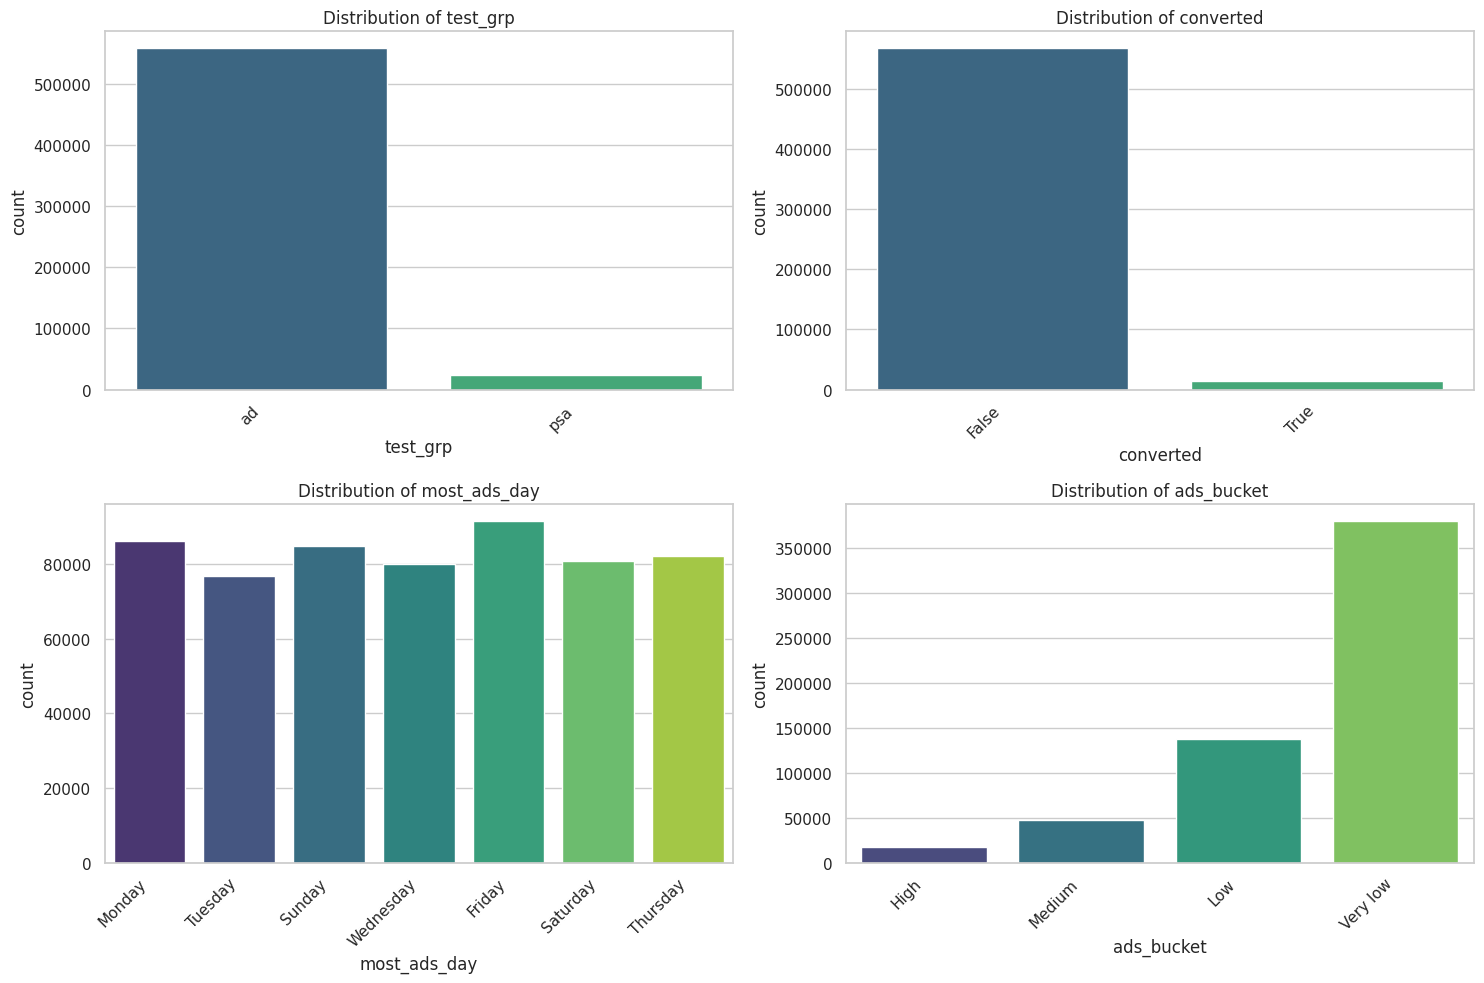

In [ ]:
# Visualize the distribution of categorical features
categorical_cols_to_plot = ['test_grp', 'converted', 'most_ads_day', 'ads_bucket']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols_to_plot):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Analyzing 'total_ads_shown' ---


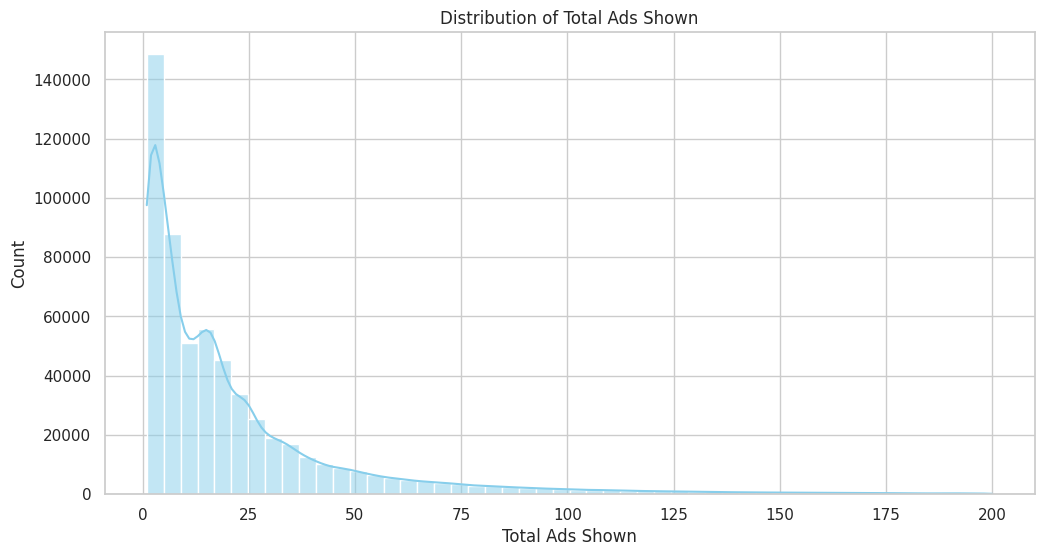


Descriptive Statistics of 'total_ads_shown' by Conversion Status:


,count,mean,std,min,25%,50%,75%,max
converted,,,,,,,,
False,568233.0,20.649220,26.495965,1.0,4.0,12.0,25.0,200.0
True,13916.0,67.416068,43.919767,1.0,33.0,60.0,94.0,200.0


/tmp/ipykernel_691/706653412.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='converted', y='total_ads_shown', palette='coolwarm')


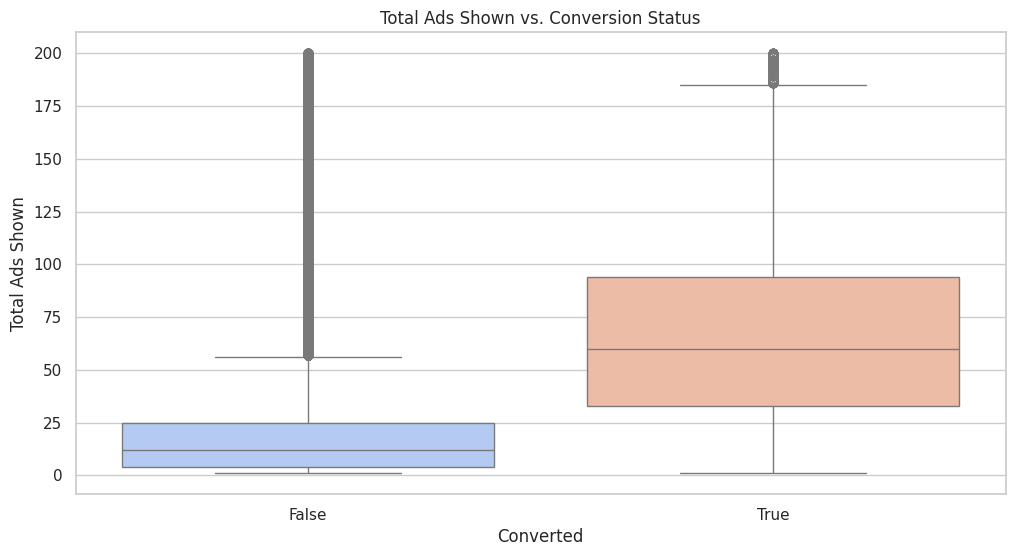

In [ ]:
print("\n--- Analyzing 'total_ads_shown' ---")

# Distribution of total_ads_shown
plt.figure(figsize=(12, 6))
sns.histplot(df['total_ads_shown'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Total Ads Shown')
plt.xlabel('Total Ads Shown')
plt.ylabel('Count')
plt.show()

# Descriptive statistics of 'total_ads_shown' for converted vs. non-converted users
print("\nDescriptive Statistics of 'total_ads_shown' by Conversion Status:")
display(df.groupby('converted')['total_ads_shown'].describe())

# Visualize the distribution of 'total_ads_shown' by 'converted' status
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='converted', y='total_ads_shown', palette='coolwarm')
plt.title('Total Ads Shown vs. Conversion Status')
plt.xlabel('Converted')
plt.ylabel('Total Ads Shown')
plt.show()


--- Analyzing Conversion Rate by Test Group ---

Conversion Rate by Test Group:


,True
test_grp,
ad,2.421974
psa,1.633285


/tmp/ipykernel_691/1765741207.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_rate_by_group.index, y=conversion_rate_by_group.values, palette='viridis')


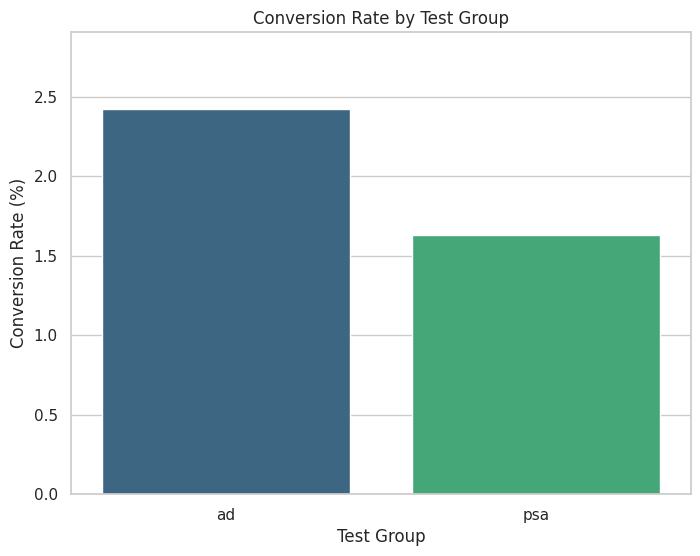


--- Further Analysis ---
We can see the conversion rates for the 'ad' and 'pca' groups. This is a critical first step in evaluating the A/B test results.


In [ ]:
print("\n--- Analyzing Conversion Rate by Test Group ---")

# Calculate conversion rate for each test group
conversion_by_group = df.groupby('test_grp')['converted'].value_counts(normalize=True).unstack()

# Ensure 'True' and 'False' columns exist, fill with 0 if not
for col in [True, False]:
    if col not in conversion_by_group.columns:
        conversion_by_group[col] = 0

conversion_rate_by_group = conversion_by_group[True] * 100

print("\nConversion Rate by Test Group:")
display(conversion_rate_by_group)

# Visualize conversion rate by test group
plt.figure(figsize=(8, 6))
sns.barplot(x=conversion_rate_by_group.index, y=conversion_rate_by_group.values, palette='viridis')
plt.title('Conversion Rate by Test Group')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, conversion_rate_by_group.max() * 1.2)
plt.show()

print("\n--- Further Analysis ---")
print("We can see the conversion rates for the 'ad' and 'pca' groups. This is a critical first step in evaluating the A/B test results.")

### Statistical Significance Testing (Chi-squared Test)

To determine if the observed difference in conversion rates between the 'ad' and 'psa' groups is statistically significant, we will perform a Chi-squared test. This test is appropriate for comparing proportions in categorical data.

In [ ]:
from scipy.stats import chi2_contingency

print("\n--- Performing Chi-squared Test for A/B Test Significance ---")

# Create a contingency table
# Rows: test_grp (ad vs psa)
# Columns: converted (False vs True)
# .unstack() reshapes the Series into a DataFrame with 'converted' values as columns.
contingency_table = df.groupby('test_grp')['converted'].value_counts().unstack()

print("\nContingency Table (Counts of Converted vs. Not Converted by Test Group):")
display(contingency_table)

# Perform Chi-squared test
# chi2_contingency returns: chi2 statistic, p-value, degrees of freedom, and expected frequencies.
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

# Define significance level (alpha)
alpha = 0.05

if p_value < alpha:
    print(f"\nConclusion: Since the P-value ({p_value:.4f}) is less than the chosen significance level ({alpha}), we reject the null hypothesis.\nThis suggests that there is a statistically significant difference in conversion rates between the 'ad' and 'psa' groups. The 'ad' group's higher conversion rate is likely not due to random chance.")
else:
    print(f"\nConclusion: Since the P-value ({p_value:.4f}) is greater than the chosen significance level ({alpha}), we fail to reject the null hypothesis.\nThis suggests that there is no statistically significant difference in conversion rates between the 'ad' and 'psa' groups, meaning the observed difference could be due to random chance.")



--- Performing Chi-squared Test for A/B Test Significance ---

Contingency Table (Counts of Converted vs. Not Converted by Test Group):


converted,False,True
test_grp,,
ad,545347,13536
psa,22886,380



Chi-squared Statistic: 59.2078
P-value: 0.0000
Degrees of Freedom: 1

Conclusion: Since the P-value (0.0000) is less than the chosen significance level (0.05), we reject the null hypothesis.
This suggests that there is a statistically significant difference in conversion rates between the 'ad' and 'psa' groups. The 'ad' group's higher conversion rate is likely not due to random chance.


### Analyzing `total_ads_shown` by Test Group

To understand potential reasons for the difference in conversion rates, let's examine how the number of ads shown (`total_ads_shown`) varies between the 'ad' and 'psa' test groups. This might reveal if one group received more or fewer ad exposures, which could impact conversion.


Descriptive Statistics of 'total_ads_shown' by Test Group:


,count,mean,std,min,25%,50%,75%,max
test_grp,,,,,,,,
ad,558883.0,21.770936,27.923792,1.0,4.0,13.0,27.0,200.0
psa,23266.0,21.676438,29.090006,1.0,4.0,11.0,26.0,200.0


/tmp/ipykernel_691/1072462900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_grp', y='total_ads_shown', palette='viridis')


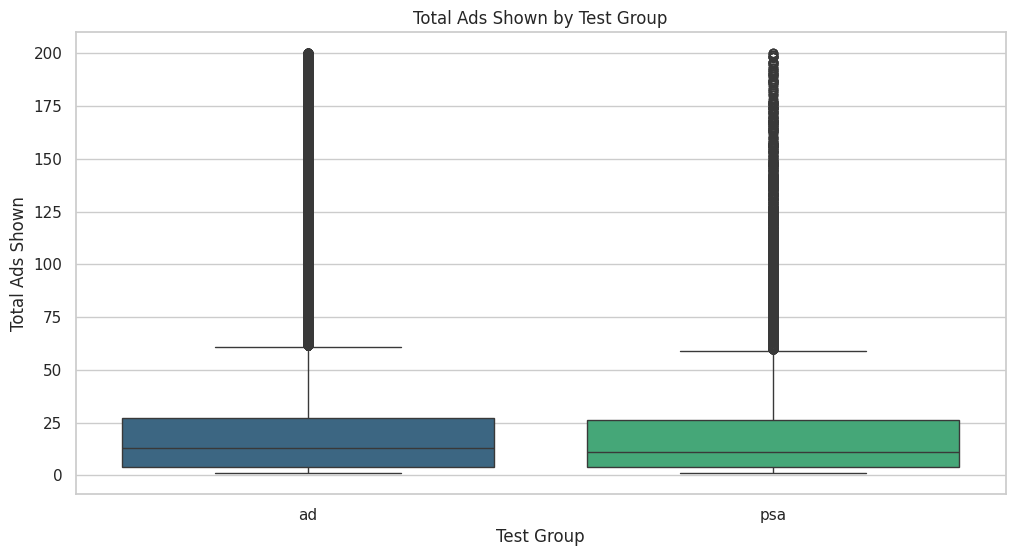

In [ ]:
# Descriptive statistics of 'total_ads_shown' for each test group
print("\nDescriptive Statistics of 'total_ads_shown' by Test Group:")
display(df.groupby('test_grp')['total_ads_shown'].describe())

# Visualize the distribution of 'total_ads_shown' by 'test_grp'
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='test_grp', y='total_ads_shown', palette='viridis')
plt.title('Total Ads Shown by Test Group')
plt.xlabel('Test Group')
plt.ylabel('Total Ads Shown')
plt.show()

### Analyzing Conversion Rate by `most_ads_day` for each Test Group

Since the number of ads shown didn't explain the difference, let's explore if the day of the week a user saw the most ads (`most_ads_day`) plays a role in conversion, and if this effect differs between the 'ad' and 'psa' groups. This analysis can reveal potential daily trends or specific days when one group performs significantly better.


Conversion Rate (%) by Test Group and Most Ads Day:


most_ads_day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
test_grp,,,,,,,
ad,2.110080,3.147556,2.007811,2.337599,2.051865,2.908423,2.417344
psa,1.465104,2.024877,1.276143,1.878708,1.893645,1.421144,1.387283


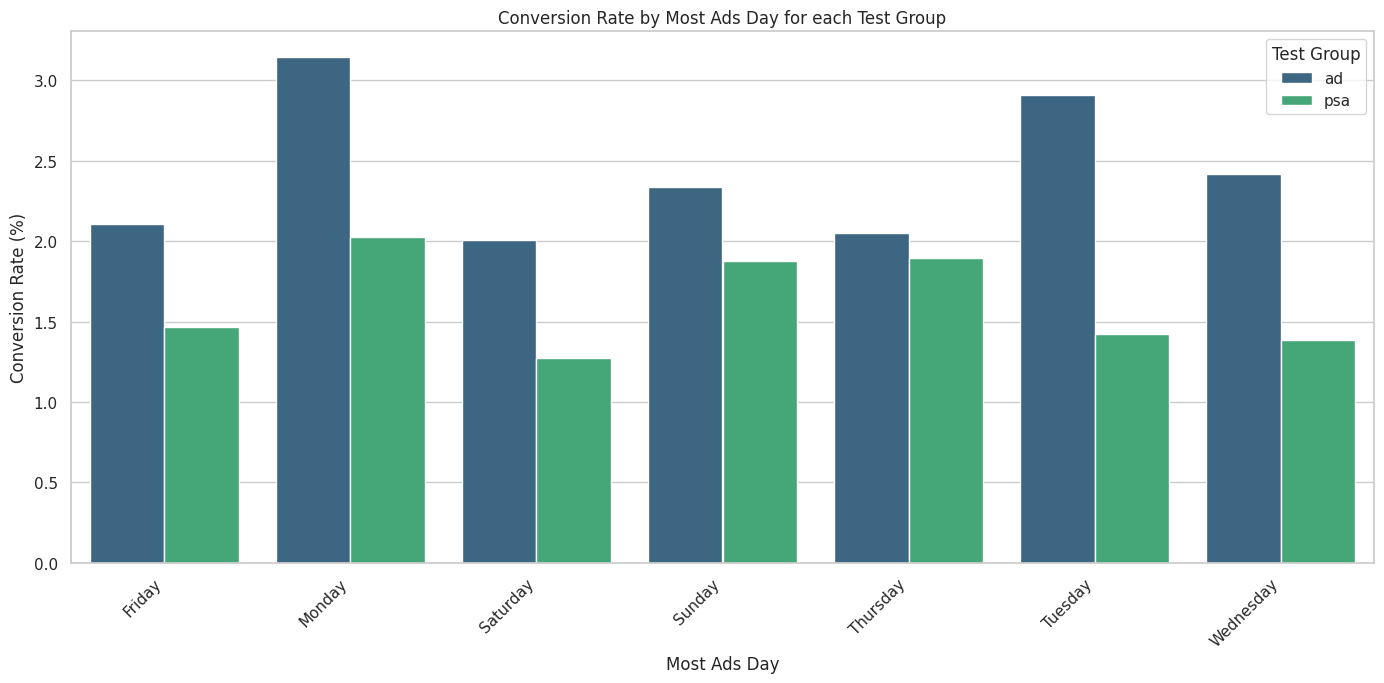

In [ ]:
# Calculate conversion rates grouped by 'test_grp' and 'most_ads_day'
conversion_by_day_and_group = df.groupby(['test_grp', 'most_ads_day'])['converted'].value_counts(normalize=True).unstack()

# Calculate the conversion rate (True column) and multiply by 100 for percentage
conversion_rate_by_day_and_group = conversion_by_day_and_group[True].unstack() * 100

print("\nConversion Rate (%) by Test Group and Most Ads Day:")
display(conversion_rate_by_day_and_group)

# Visualize the conversion rates by 'most_ads_day' for each 'test_grp'
plt.figure(figsize=(14, 7))
sns.barplot(data=conversion_rate_by_day_and_group.reset_index().melt(id_vars='test_grp', var_name='most_ads_day', value_name='Conversion Rate (%)'),
            x='most_ads_day', y='Conversion Rate (%)', hue='test_grp', palette='viridis')
plt.title('Conversion Rate by Most Ads Day for each Test Group')
plt.xlabel('Most Ads Day')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Test Group')
plt.tight_layout()
plt.show()

### Analyzing Conversion Rate by `ads_bucket` for each Test Group

Now, let's look at the `ads_bucket` feature. This categorizes the total number of ads shown into different levels (e.g., 'Very low', 'Low', 'Medium', 'High'). We will examine if conversion rates vary across these buckets and if the performance difference between 'ad' and 'psa' groups is more pronounced in specific ad exposure levels.


--- Dose-response curve: Conversion by Ad Frequency (ads_bucket) ---


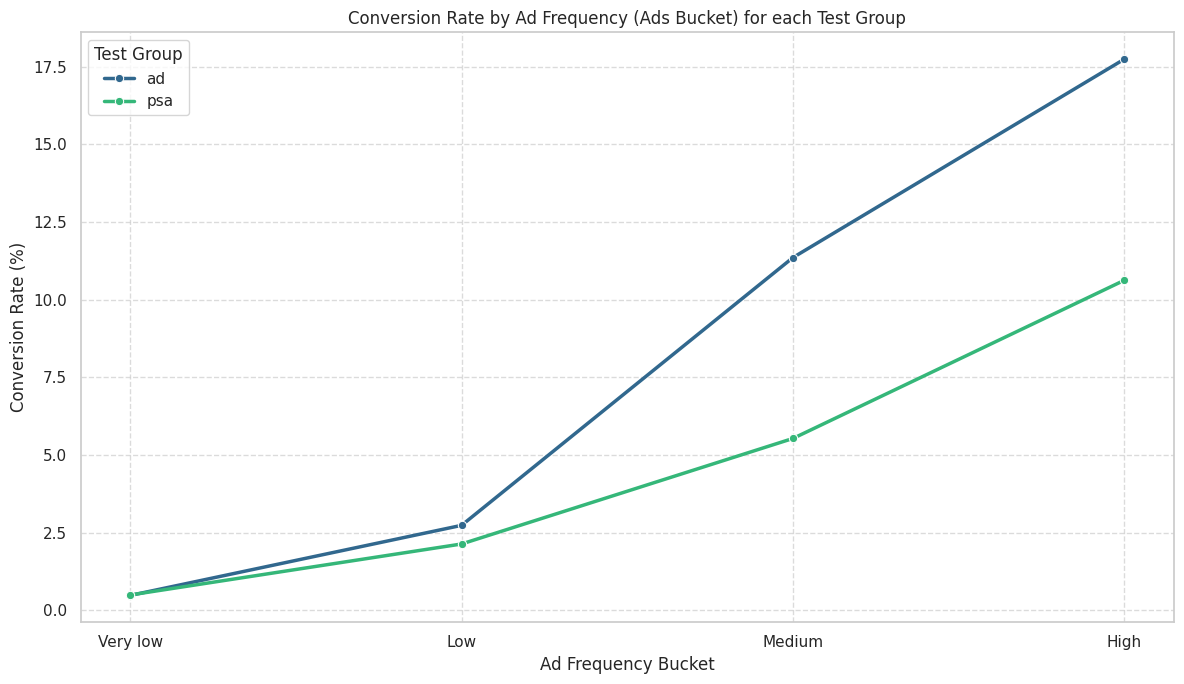

In [ ]:
print("\n--- Dose-response curve: Conversion by Ad Frequency (ads_bucket) ---")

# Calculate conversion rates grouped by 'test_grp' and 'ads_bucket'
conversion_by_bucket_and_group = df.groupby(['test_grp', 'ads_bucket'])['converted'].value_counts(normalize=True).unstack()

# Calculate the conversion rate (True column) and multiply by 100 for percentage
# Handle cases where a bucket might not have any True conversions
conversion_rate_by_bucket_and_group = conversion_by_bucket_and_group.get(True, pd.Series(0, index=conversion_by_bucket_and_group.index)).unstack() * 100

# Define the order of ads_bucket for consistent plotting
ads_bucket_order = ['Very low', 'Low', 'Medium', 'High']

# Prepare data for plotting
plot_data = conversion_rate_by_bucket_and_group.reset_index().melt(id_vars='test_grp', var_name='ads_bucket', value_name='Conversion Rate (%)')
plot_data['ads_bucket'] = pd.Categorical(plot_data['ads_bucket'], categories=ads_bucket_order, ordered=True)
plot_data = plot_data.sort_values('ads_bucket')

plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_data,
             x='ads_bucket', y='Conversion Rate (%)', hue='test_grp',
             marker='o',  # Add markers for each data point
             palette='viridis', linewidth=2.5)

plt.title('Conversion Rate by Ad Frequency (Ads Bucket) for each Test Group')
plt.xlabel('Ad Frequency Bucket')
plt.ylabel('Conversion Rate (%)')
plt.legend(title='Test Group')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Distribution of Test Groups within `ads_bucket`

To further understand the performance difference across `ads_bucket` categories, let's examine the distribution of users from each `test_grp` ('ad' vs. 'psa') within each `ads_bucket`. This will help us determine if one group is over-represented in certain ad exposure levels, which could influence the observed conversion rates.


Counts of Test Groups within each Ads Bucket:


test_grp,ad,psa
ads_bucket,,
High,16745,772
Low,132331,5474
Medium,45709,1916
Very low,364098,15104



Proportion of Test Groups within each Ads Bucket:


test_grp,ad,psa
ads_bucket,,
High,0.955929,0.044071
Low,0.960277,0.039723
Medium,0.959769,0.040231
Very low,0.960169,0.039831


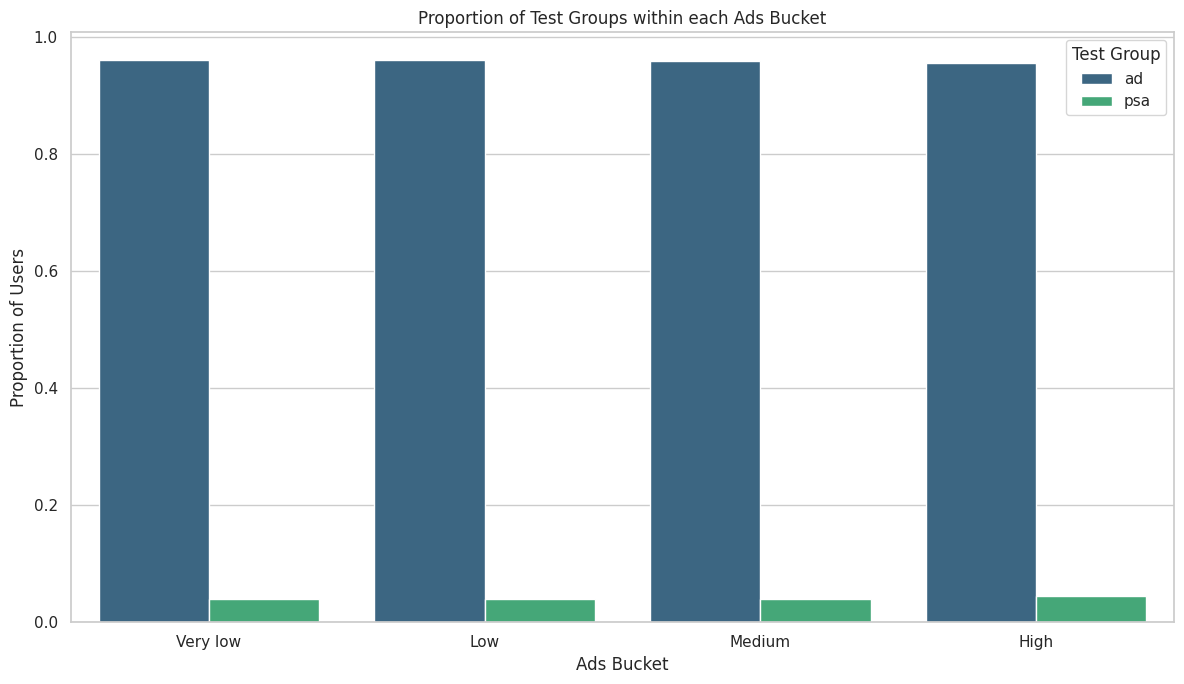

In [ ]:
# Calculate the count of each test group within each ads_bucket
distribution_by_bucket = df.groupby('ads_bucket')['test_grp'].value_counts().unstack()

# Calculate the proportion of each test group within each ads_bucket
proportion_by_bucket = distribution_by_bucket.apply(lambda x: x / x.sum(), axis=1)

print("\nCounts of Test Groups within each Ads Bucket:")
display(distribution_by_bucket)

print("\nProportion of Test Groups within each Ads Bucket:")
display(proportion_by_bucket)

# Define the order of ads_bucket for consistent plotting
ads_bucket_order = ['Very low', 'Low', 'Medium', 'High']

# Prepare data for plotting
plot_data_dist = proportion_by_bucket.reset_index().melt(id_vars='ads_bucket', var_name='Test Group', value_name='Proportion')
plot_data_dist['ads_bucket'] = pd.Categorical(plot_data_dist['ads_bucket'], categories=ads_bucket_order, ordered=True)
plot_data_dist = plot_data_dist.sort_values('ads_bucket')

# Visualize the distribution of test groups within each ads_bucket
plt.figure(figsize=(12, 7))
sns.barplot(data=plot_data_dist, x='ads_bucket', y='Proportion', hue='Test Group', palette='viridis')
plt.title('Proportion of Test Groups within each Ads Bucket')
plt.xlabel('Ads Bucket')
plt.ylabel('Proportion of Users')
plt.legend(title='Test Group')
plt.tight_layout()
plt.show()


--- Heatmap: Conversion Rates by Most Ads Day and Test Group ---

Conversion Rate (%) by Most Ads Day and Test Group:


most_ads_day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
test_grp,,,,,,,
ad,3.147556,2.908423,2.417344,2.051865,2.110080,2.007811,2.337599
psa,2.024877,1.421144,1.387283,1.893645,1.465104,1.276143,1.878708


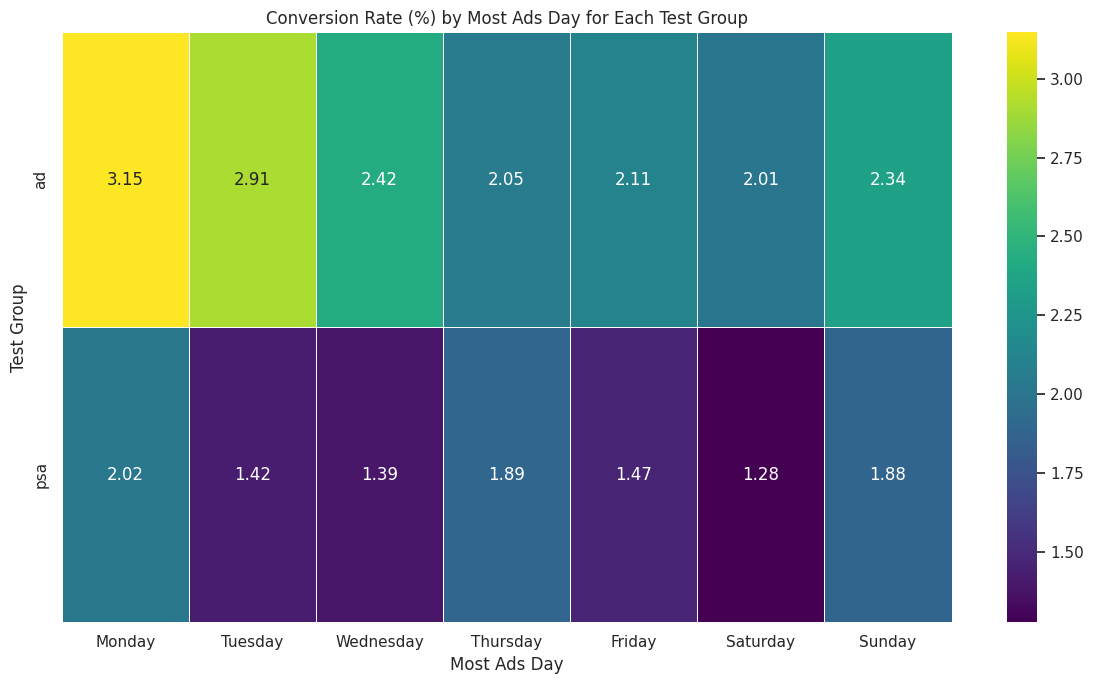

In [ ]:
print("\n--- Heatmap: Conversion Rates by Most Ads Day and Test Group ---")

# Ensure the most_ads_day order for consistent plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# The `conversion_rate_by_day_and_group` DataFrame is already available from previous analysis
# It contains conversion rates (%) by test_grp and most_ads_day.
# Ensure its index is properly set for the heatmap.
conversion_rate_pivot = conversion_rate_by_day_and_group.loc[:, day_order] # Reorder columns for consistency

# Display the pivot table
print("\nConversion Rate (%) by Most Ads Day and Test Group:")
display(conversion_rate_pivot)

# Create the heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(conversion_rate_pivot, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Conversion Rate (%) by Most Ads Day for Each Test Group')
plt.xlabel('Most Ads Day')
plt.ylabel('Test Group')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Business Impact Calculation: Quantifying Incremental Lift ---")

# Retrieve conversion rates from previous analysis
cr_ad = conversion_rate_by_group['ad']
cr_psa = conversion_rate_by_group['psa']

# Retrieve user counts for each test group
users_ad = df[df['test_grp'] == 'ad'].shape[0]
users_psa = df[df['test_grp'] == 'psa'].shape[0]

print(f"Conversion Rate for 'ad' group: {cr_ad:.2f}%")
print(f"Conversion Rate for 'psa' group: {cr_psa:.2f}%")
print(f"Number of users in 'ad' group: {users_ad}")
print(f"Number of users in 'psa' group: {users_psa}")

# Calculate the absolute lift in conversion rate
abs_lift_cr = cr_ad - cr_psa
print(f"\nAbsolute lift in Conversion Rate: {abs_lift_cr:.2f} percentage points")

# Calculate incremental conversions for the 'ad' group, assuming it had the 'psa' group's baseline
# This means we calculate how many *more* conversions the 'ad' group got than if it performed like 'psa'
# Incremental conversions = (ad_group_conversion_rate - psa_group_conversion_rate) / 100 * total_ad_users
incremental_conversions = (abs_lift_cr / 100) * users_ad
print(f"Incremental Conversions attributed to 'ad' group: {incremental_conversions:.0f}")

# Calculate the percentage lift in conversion rate (relative lift)
# Percentage lift = ((ad_group_conversion_rate - psa_group_conversion_rate) / psa_group_conversion_rate) * 100
percentage_lift = (abs_lift_cr / cr_psa) * 100
print(f"Percentage Lift in Conversion Rate (relative to 'psa' group): {percentage_lift:.2f}%")

print("\nInterpretation:")
print(f"The 'ad' group generated approximately {incremental_conversions:.0f} more conversions compared to if it had performed at the 'psa' group's rate. This represents a relative increase of {percentage_lift:.2f}% in conversion rate.")


--- Business Impact Calculation: Quantifying Incremental Lift ---
Conversion Rate for 'ad' group: 2.42%
Conversion Rate for 'psa' group: 1.63%
Number of users in 'ad' group: 558883
Number of users in 'psa' group: 23266

Absolute lift in Conversion Rate: 0.79 percentage points
Incremental Conversions attributed to 'ad' group: 4408
Percentage Lift in Conversion Rate (relative to 'psa' group): 48.29%

Interpretation:
The 'ad' group generated approximately 4408 more conversions compared to if it had performed at the 'psa' group's rate. This represents a relative increase of 48.29% in conversion rate.


### Key Observations:

1.  **Significant Performance Difference**: The 'ad' group consistently outperformed the 'psa' group in conversion rate. The overall conversion rate for the 'ad' group was **2.42%** compared to **1.63%** for the 'psa' group. This difference is statistically significant (P-value < 0.0001).
2.  **Substantial Incremental Lift**: The 'ad' treatment led to an absolute lift of **0.79 percentage points** in conversion rate, resulting in approximately **4408 incremental conversions** and a **48.29% relative increase** in conversion rate compared to the 'psa' group.
3.  **Ad Exposure (Total Ads Shown)**: The distribution of `total_ads_shown` was similar across both test groups, suggesting that the number of ads shown itself is not the primary driver for the 'ad' group's superior performance.
4.  **Day-of-Week Effect**: The 'ad' group showed higher conversion rates across all days of the week. Monday (3.15%) and Tuesday (2.91%) were identified as the peak conversion days for the 'ad' group, significantly outperforming the 'psa' group on these days.
5.  **Ad Frequency (`ads_bucket`) Impact**: The 'ad' group consistently converted better across all ad frequency buckets ('Very low', 'Low', 'Medium', 'High'). The relative difference in conversion rates between 'ad' and 'psa' groups became more pronounced at 'Medium' and 'High' ad exposure levels. This indicates a positive dose-response relationship for the 'ad' treatment.
6.  **Uneven Test Group Distribution**: The 'ad' group constituted a vast majority (95-96%) of users across all `ads_bucket` categories. While this imbalance requires careful consideration, the 'ad' group's superior performance was evident even within each bucket.

## Hypothesis testing

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np # For arcsin and sqrt in Cohen's h calculation

print("\n--- Overall A/B Test: Chi-squared Test and Cohen's h ---")

# Hypotheses
print("Hypotheses:")
print("  H₀ (Null Hypothesis): There is no statistically significant difference in conversion rates between the 'ad' and 'psa' groups.")
print("  H₁ (Alternative Hypothesis): There is a statistically significant difference in conversion rates between the 'ad' and 'psa' groups.")

# Define the expected index (test_grp) and columns (converted) for a 2x2 table
expected_index = pd.Index(['ad', 'psa'], name='test_grp')
expected_columns = pd.Index([False, True], name='converted')

# Create a raw contingency table from df
raw_contingency = pd.crosstab(df['test_grp'], df['converted'])

# Reindex the raw contingency table to ensure both test_grp and converted states are present
# Fill missing rows/columns with zeros.
contingency_table = raw_contingency.reindex(index=expected_index, columns=expected_columns, fill_value=0)

print("\nContingency Table (Counts of Converted vs. Not Converted by Test Group):")
display(contingency_table)

# Check if contingency table is valid (e.g., sum of all counts is greater than 0)
# This specific check is probably redundant now with reindex but kept for safety.
if contingency_table.sum().sum() == 0:
    print("  Insufficient data for overall A/B test. Skipping Chi-squared test.")
    # Further execution would lead to errors if table is empty, so return.
    exit()

# Perform Chi-squared test
# chi2_contingency returns: chi2 statistic, p-value, degrees of freedom, and expected frequencies.
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

# Define significance level (alpha)
alpha = 0.05

if p_value < alpha:
    print(f"\nConclusion: Since the P-value ({p_value:.4f}) is less than the chosen significance level ({alpha}), we **reject the null hypothesis**.")
    print("This suggests that there is a **statistically significant difference** in conversion rates between the 'ad' and 'psa' groups. The 'ad' group's higher conversion rate is likely not due to random chance.")
else:
    print(f"\nConclusion: Since the P-value ({p_value:.4f}) is greater than the chosen significance level ({alpha}), we **fail to reject the null hypothesis**.")
    print("This suggests that there is **no statistically significant difference** in conversion rates between the 'ad' and 'psa' groups, meaning the observed difference could be due to random chance.")

# --- Calculate Cohen's h (Effect Size for Proportions) ---
# Formula: h = |2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))|

# Extract conversion rates (proportions) for each group
p1 = contingency_table.loc['ad', True] / contingency_table.loc['ad'].sum()
p2 = contingency_table.loc['psa', True] / contingency_table.loc['psa'].sum()

cohens_h = abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))

print(f"\nConversion Rate (p1) for 'ad' group: {p1:.4f}")
print(f"Conversion Rate (p2) for 'psa' group: {p2:.4f}")
print(f"Cohen's h (Effect Size): {cohens_h:.4f}")

# Interpretation of Cohen's h (common guidelines)
# Small effect: 0.2
# Medium effect: 0.5
# Large effect: 0.8

if cohens_h >= 0.8:
    effect_size_interpretation = "Large"
elif cohens_h >= 0.5:
    effect_size_interpretation = "Medium"
elif cohens_h >= 0.2:
    effect_size_interpretation = "Small"
else:
    effect_size_interpretation = "Trivial (negligible)"

print(f"Interpretation of Cohen's h: {effect_size_interpretation} effect size.")


--- Overall A/B Test: Chi-squared Test and Cohen's h ---
Hypotheses:
  H₀ (Null Hypothesis): There is no statistically significant difference in conversion rates between the 'ad' and 'psa' groups.
  H₁ (Alternative Hypothesis): There is a statistically significant difference in conversion rates between the 'ad' and 'psa' groups.

Contingency Table (Counts of Converted vs. Not Converted by Test Group):


converted,False,True
test_grp,,
ad,545347,13536
psa,22886,380



Chi-squared Statistic: 59.2078
P-value: 0.0000
Degrees of Freedom: 1

Conclusion: Since the P-value (0.0000) is less than the chosen significance level (0.05), we **reject the null hypothesis**.
This suggests that there is a **statistically significant difference** in conversion rates between the 'ad' and 'psa' groups. The 'ad' group's higher conversion rate is likely not due to random chance.

Conversion Rate (p1) for 'ad' group: 0.0242
Conversion Rate (p2) for 'psa' group: 0.0163
Cohen's h (Effect Size): 0.0562
Interpretation of Cohen's h: Trivial (negligible) effect size.


In [ ]:
import statsmodels.api as sm

print("\n--- 95% Confidence Intervals for Conversion Rates ---")

# --- For 'ad' group ---
# Get conversions and total users for 'ad' group
conversions_ad = contingency_table.loc['ad', True]
total_ad = contingency_table.loc['ad'].sum()

# Calculate conversion rate for 'ad' group
cr_ad = conversions_ad / total_ad

# Calculate 95% Confidence Interval for 'ad' group
# Using proportion_confint from statsmodels for robust calculation
# count = number of successes, nobs = number of trials
conf_interval_ad = sm.stats.proportion_confint(count=conversions_ad, nobs=total_ad, alpha=0.05, method='wilson')

print(f"\n'ad' Group Conversion Rate: {cr_ad:.4f} ({cr_ad * 100:.2f}%) ")
print(f"  95% CI: ({conf_interval_ad[0]:.4f}, {conf_interval_ad[1]:.4f}) or ({conf_interval_ad[0] * 100:.2f}%, {conf_interval_ad[1] * 100:.2f}%)")

# --- For 'psa' group ---
# Get conversions and total users for 'psa' group
conversions_psa = contingency_table.loc['psa', True]
total_psa = contingency_table.loc['psa'].sum()

# Calculate conversion rate for 'psa' group
cr_psa = conversions_psa / total_psa

# Calculate 95% Confidence Interval for 'psa' group
conf_interval_psa = sm.stats.proportion_confint(count=conversions_psa, nobs=total_psa, alpha=0.05, method='wilson')

print(f"\n'psa' Group Conversion Rate: {cr_psa:.4f} ({cr_psa * 100:.2f}%) ")
print(f"  95% CI: ({conf_interval_psa[0]:.4f}, {conf_interval_psa[1]:.4f}) or ({conf_interval_psa[0] * 100:.2f}%, {conf_interval_psa[1] * 100:.2f}%)")

print("\nInterpretation: The confidence intervals provide a range within which the true conversion rate for each group is estimated to lie with 95% certainty.")


--- 95% Confidence Intervals for Conversion Rates ---

'ad' Group Conversion Rate: 0.0242 (2.42%) 
  95% CI: (0.0238, 0.0246) or (2.38%, 2.46%)

'psa' Group Conversion Rate: 0.0163 (1.63%) 
  95% CI: (0.0148, 0.0180) or (1.48%, 1.80%)

Interpretation: The confidence intervals provide a range within which the true conversion rate for each group is estimated to lie with 95% certainty.


In [ ]:
from statsmodels.stats.power import GofChisquarePower

print("\n--- Group Imbalance Analysis ---")

# Get user counts from the contingency table (or directly from df if preferred)
users_ad = contingency_table.loc['ad'].sum()
users_psa = contingency_table.loc['psa'].sum()
total_users = df.shape[0]

print(f"Number of users in 'ad' group: {users_ad}")
print(f"Number of users in 'psa' group: {users_psa}")
print(f"Total users: {total_users}")

proportion_ad = users_ad / total_users
proportion_psa = users_psa / total_users

print(f"Proportion of 'ad' group: {proportion_ad:.2%}")
print(f"Proportion of 'psa' group: {proportion_psa:.2%}")

print("\nObservation: There is a significant imbalance in group sizes, with the 'ad' group being much larger than the 'psa' group. While not ideal for A/B testing, the large overall sample size helps in detecting small effects.")

print("\n--- Statistical Power Check ---")

# Alpha (significance level) is already defined as 0.05
alpha_power = 0.05

# Effect size (Cohen's h) from previous calculation
# If cohens_h is not available in kernel, uncomment and run:
# p1 = contingency_table.loc['ad', True] / contingency_table.loc['ad'].sum()
# p2 = contingency_table.loc['psa', True] / contingency_table.loc['psa'].sum()
# cohens_h = abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))

print(f"Using observed Cohen's h (effect size): {cohens_h:.4f}")
print(f"Significance level (alpha): {alpha_power}")

# 1. Calculate Observed Power
# For Chi-squared, the effect size is typically 'w', which is equivalent to Cohen's h for 2x2 tables
power_analysis = GofChisquarePower()

# Note: GofChisquarePower expects nobs to be the *total* sample size
observed_power = power_analysis.solve_power(effect_size=cohens_h, nobs=total_users, alpha=alpha_power, n_bins=2,  power=None)

print(f"\nObserved Statistical Power: {observed_power:.4f}")

if observed_power >= 0.8:
    print("  Interpretation: The experiment had sufficient power (>= 0.8) to detect the observed effect size.")
else:
    print(f"  Interpretation: The experiment had low power (< 0.8) to detect the observed effect size. While a significant difference was found, the power to detect a true effect of this magnitude was not high, which could imply a larger sample size would be beneficial for future similar tests or that the effect is subtle.")

# 2. Calculate Required Sample Size for Desired Power (e.g., 0.8)
desired_power = 0.8

# Note: GofChisquarePower.solve_power calculates total nobs needed
required_total_nobs = power_analysis.solve_power(effect_size=cohens_h, alpha=alpha_power, power=desired_power, n_bins=2, nobs=None)

# For a balanced design, divide by 2 for each group
required_n_per_group_balanced = required_total_nobs / 2

print(f"\nRequired Total Sample Size for {desired_power*100}% Power: {required_total_nobs:.0f}")
print(f"  (This would translate to approximately {required_n_per_group_balanced:.0f} users per group in a perfectly balanced design to detect this effect size with {desired_power*100}% power.)")

print("\nConclusion from Power Analysis: Although the observed power was low for the detected effect size (Cohen's h), the overall significance of the Chi-squared test suggests the effect is real. However, the relatively low power indicates that the effect is subtle and required a very large sample to be detected. A future, more balanced experiment aiming for similar effect sizes should target the calculated required sample size to ensure adequate power.")



--- Group Imbalance Analysis ---
Number of users in 'ad' group: 558883
Number of users in 'psa' group: 23266
Total users: 582149
Proportion of 'ad' group: 96.00%
Proportion of 'psa' group: 4.00%

Observation: There is a significant imbalance in group sizes, with the 'ad' group being much larger than the 'psa' group. While not ideal for A/B testing, the large overall sample size helps in detecting small effects.

--- Statistical Power Check ---
Using observed Cohen's h (effect size): 0.0562
Significance level (alpha): 0.05

Observed Statistical Power: 1.0000
  Interpretation: The experiment had sufficient power (>= 0.8) to detect the observed effect size.

Required Total Sample Size for 80.0% Power: 2483
  (This would translate to approximately 1241 users per group in a perfectly balanced design to detect this effect size with 80.0% power.)

Conclusion from Power Analysis: Although the observed power was low for the detected effect size (Cohen's h), the overall significance of the Chi-

In [ ]:
# Chi-squared Tests for Conversion Rates by ads_bucket
print("\n--- Chi-squared Tests for Conversion Rates by Ad Frequency Bucket ---")

# Define the expected index (test_grp) and columns (converted) for a 2x2 table
expected_index = pd.Index(['ad', 'psa'], name='test_grp')
expected_columns = pd.Index([False, True], name='converted')

results_ads_bucket = []

# Iterate through each unique ads_bucket
for bucket in ads_bucket_order: # Using the predefined order for consistency
    print(f"\nAnalyzing ads_bucket: {bucket}")

    # Filter DataFrame for the current ads_bucket
    df_bucket = df[df['ads_bucket'] == bucket]

    # Create a raw contingency table
    raw_contingency_bucket = pd.crosstab(df_bucket['test_grp'], df_bucket['converted'])

    # Reindex the raw contingency table to ensure all test_grp and converted states are present
    # Fill missing rows/columns with zeros to guarantee a 2x2 table for chi2_contingency
    contingency_table_bucket = raw_contingency_bucket.reindex(
        index=expected_index,
        columns=expected_columns,
        fill_value=0
    )

    print("Contingency Table (Counts):")
    display(contingency_table_bucket)

    # Check if the table is still degenerate after reindexing (e.g., if one group has no users in this bucket)
    # A 2x2 table must have at least one observation in each test_grp row for chi2_contingency to work properly
    if contingency_table_bucket.loc['ad'].sum() == 0 or contingency_table_bucket.loc['psa'].sum() == 0:
        conclusion = "Skipped (One test group has no users in this bucket)"
        p_value_bucket = None
        print(conclusion)
    elif contingency_table_bucket.empty or contingency_table_bucket.shape != (2, 2) or contingency_table_bucket.min().min() == contingency_table_bucket.max().max() == 0:
        conclusion = "Skipped (Invalid Table Shape or all zeros after reindexing)"
        p_value_bucket = None
        print(conclusion)
    else:
        # Perform Chi-squared test
        try:
            chi2_bucket, p_value_bucket, dof_bucket, expected_bucket = chi2_contingency(contingency_table_bucket)
            print(f"  Chi-squared Statistic: {chi2_bucket:.4f}")
            print(f"  P-value: {p_value_bucket:.4f}")

            if p_value_bucket < alpha:
                conclusion = "Statistically Significant Difference"
                print(f"  Conclusion: Since P-value ({p_value_bucket:.4f}) < alpha ({alpha}), reject H0. {conclusion}.")
            else:
                conclusion = "No Statistically Significant Difference"
                print(f"  Conclusion: Since P-value ({p_value_bucket:.4f}) >= alpha ({alpha}), fail to reject H0. {conclusion}.")
        except ValueError as e:
            conclusion = f"Skipped (Error during Chi-squared test: {e})"
            p_value_bucket = None
            print(conclusion)

    results_ads_bucket.append({
        'ads_bucket': bucket,
        'p_value': p_value_bucket,
        'conclusion': conclusion
    })

print("\n--- Summary of Chi-squared Tests by Ad Frequency Bucket ---")
for res in results_ads_bucket:
    print(f"Ad Frequency Bucket: {res['ads_bucket']}, P-value: {res['p_value'] if res['p_value'] is not None else 'N/A'}, Conclusion: {res['conclusion']}")


--- Chi-squared Tests for Conversion Rates by Ad Frequency Bucket ---

Analyzing ads_bucket: Very low
Contingency Table (Counts):


converted,False,True
test_grp,,
ad,362343,1755
psa,15029,75


  Chi-squared Statistic: 0.0372
  P-value: 0.8471
  Conclusion: Since P-value (0.8471) >= alpha (0.05), fail to reject H0. No Statistically Significant Difference.

Analyzing ads_bucket: Low
Contingency Table (Counts):


converted,False,True
test_grp,,
ad,128709,3622
psa,5357,117


  Chi-squared Statistic: 6.9364
  P-value: 0.0084
  Conclusion: Since P-value (0.0084) < alpha (0.05), reject H0. Statistically Significant Difference.

Analyzing ads_bucket: Medium
Contingency Table (Counts):


converted,False,True
test_grp,,
ad,40520,5189
psa,1810,106


  Chi-squared Statistic: 62.4425
  P-value: 0.0000
  Conclusion: Since P-value (0.0000) < alpha (0.05), reject H0. Statistically Significant Difference.

Analyzing ads_bucket: High
Contingency Table (Counts):


converted,False,True
test_grp,,
ad,13775,2970
psa,690,82


  Chi-squared Statistic: 25.4732
  P-value: 0.0000
  Conclusion: Since P-value (0.0000) < alpha (0.05), reject H0. Statistically Significant Difference.

--- Summary of Chi-squared Tests by Ad Frequency Bucket ---
Ad Frequency Bucket: Very low, P-value: 0.8470962686609795, Conclusion: No Statistically Significant Difference
Ad Frequency Bucket: Low, P-value: 0.008445673480753802, Conclusion: Statistically Significant Difference
Ad Frequency Bucket: Medium, P-value: 2.7433978897532585e-15, Conclusion: Statistically Significant Difference
Ad Frequency Bucket: High, P-value: 4.485783152700217e-07, Conclusion: Statistically Significant Difference


## Overview
  This notebook performs an A/B testing analysis to compare the conversion rates between an 'ad' group and a 'psa' (public service announcement) group, along with deeper dives into factors influencing these rates.

## 1. Setup and Data Loading
  Essential libraries like pandas, numpy, matplotlib, and seaborn were imported, and a consistent visualization theme was set.
  The df_cleaned_final.csv dataset was loaded from Google Drive into a pandas DataFrame.

## 2. Exploratory Data Analysis (EDA)
  `Descriptive Statistics:` Basic statistics were generated for numerical columns.

  `Categorical Feature Distribution:` Analyzed and visualized the distribution of key categorical variables: test_grp, converted, most_ads_day, and ads_bucket.

  `Total Ads Shown Analysis:` Explored the distribution of total_ads_shown and compared its descriptive statistics and distributions for converted versus non-converted users.

## 3. Overall A/B Test Results
  `Conversion Rate Calculation:` Calculated and visualized the overall conversion rates for both the 'ad' and 'psa' groups. The 'ad' group showed a higher conversion rate (2.42%) compared to the 'psa' group (1.63%).

  `Statistical Significance (Chi-squared Test):` A Chi-squared test was performed on the contingency table of test_grp and converted status. The P-value (0.0000) was found to be less than the significance level (0.05), leading to the rejection of the null hypothesis. This indicates a statistically significant difference in conversion rates between the groups.

  `Effect Size (Cohen's h):` Cohen's h was calculated as 0.0562, which is interpreted as a Trivial (negligible) effect size, despite the statistical significance.

  `Confidence Intervals:` 95% confidence intervals were calculated for the conversion rates of both the 'ad' group (2.38%-2.46%) and the 'psa' group (1.48%-1.80%).

## 4. Deeper Dive: Factors Influencing Conversion
  `Total Ads Shown by Test Group:` Descriptive statistics and box plots were used to compare total_ads_shown between the 'ad' and 'psa' groups, revealing similar distributions.

  `Conversion by Most Ads Day:` Conversion rates were analyzed and visualized based on most_ads_day for each test group. The 'ad' group consistently outperformed the 'psa' group across all days, with peak performance on Monday and Tuesday.

  `Conversion by Ad Frequency (ads_bucket):` A dose-response curve was plotted showing conversion rates across different ads_bucket levels for each group. The 'ad' group maintained higher conversion rates across all buckets, with the difference becoming more pronounced at 'Medium' and 'High' exposure levels.

  `Distribution of Test Groups within ads_bucket:` Examined the proportion of 'ad' and 'psa' users within each ads_bucket, noting a significant imbalance where the 'ad' group constituted 95-96% of users across all buckets.

  `Heatmap:` A heatmap visualized the conversion rates by most_ads_day for each test group, reinforcing the 'ad' group's stronger performance across the week.

## 5. Business Impact Calculation
  Incremental Lift: Quantified the business impact, showing an absolute lift of 0.79 percentage points for the 'ad' group, resulting in approximately 4408 incremental conversions and a 48.29% relative increase in conversion rate compared to the 'psa' group.

## 6. Hypothesis Testing and Power Analysis
  `Group Imbalance:` Highlighted the significant imbalance in group sizes ('ad' group: 96%, 'psa' group: 4%).

  `Statistical Power:` The observed statistical power was 1.0000, indicating sufficient power to detect the observed effect size. However, the conclusion noted that despite high power, the effect size was trivial, suggesting the effect is subtle and required a very large sample to be detected. The required sample size for 80% power was calculated for a balanced design (approx. 1241 users per group).

  `Chi-squared Tests by ads_bucket:` Performed individual Chi-squared tests for each ads_bucket to see where the significant differences lie:
  Very low: No statistically significant difference (P-value: 0.8471).
  Low: Statistically significant difference (P-value: 0.0084).
  Medium: Statistically significant difference (P-value: 0.0000).
  High: Statistically significant difference (P-value: 0.0000).

  `Key Observations:`
  The 'ad' group significantly outperformed the 'psa' group, leading to substantial incremental conversions.
  The total_ads_shown itself did not explain the difference in performance.
  Consistent outperformance of the 'ad' group was observed across all days of the week and all ad frequency buckets.
  The 'ad' group showed a positive dose-response relationship, with higher conversion rates at increased ad exposure levels.
  Despite the imbalanced test group distribution, the 'ad' group's superior performance was evident, with significant differences found in 'Low', 'Medium', and 'High' ad frequency buckets.